In [ ]:
"""MODEL B — DSI Forecaster (ConvGRU-UNet Seq2Seq)
================================================
Spatio-temporal forecasting: quarterly-sampled DSI history -> quarterly-sampled DSI forecast

TRAINING config (seq_len=12, step_size=3):
  Input:  (B, 12, 1, 64, 64) — 12 DSI maps (channel 37), sampled every 3rd month
                                -> spans 34 calendar months (~2.8 years) of history
  Output: (B, 12, 1, 64, 64) — next 12 DSI maps, sampled every 3rd month
                                -> spans the following 34 calendar months (~2.8 years)

TESTING config (seq_len=4, step_size=3):
  Input:  (B, 4, 1, 64, 64)  — 4 DSI maps (channel 37), sampled every 3rd month
                                -> spans 10 calendar months of history
  Output: (B, 4, 1, 64, 64)  — next 4 DSI maps, sampled every 3rd month
                                -> spans the following 10 calendar months
  (Train and test use different seq_len because the 26-month test set cannot
   support the seq_len=12 footprint of 70 months. step_size=3 is kept
   IDENTICAL on both sides so the model's learned notion of "how much
   change happens per step" stays consistent between training and eval --
   changing step_size between train/test would be a worse mismatch than
   changing seq_len, since it changes what a "step" physically means.)

Architecture:
  Shared CNN Encoder  — spatial compression per timestep
  ConvGRU Encoder     — temporal state transfer across input steps
  ConvGRU Decoder     — autoregressive unrolling of future steps
  CNN Decoder         — spatial recovery via skip connections

Training data construction (seq_len=12, step_size=3, window-start stride=1):
  Footprint per window = (2*seq_len - 1) * step_size + 1 = 70 months
  Train: 400 patches x 27 windows/patch = 10,800 samples
  Val:   100 patches x 27 windows/patch =  2,700 samples
  Input:  DSI[t, t+3, t+6, ..., t+33]   channel 37  (12 samples, 3-month spacing)
  Target: DSI[t+36, t+39, ..., t+69]    channel 37  (12 samples, 3-month spacing)
  NOTE: window START advances by 1 month per sample ("stride=1" refers only
  to this) -- but each window itself samples months every 3rd month
  (step_size=3), NOT consecutively. These are two different strides;
  don't conflate them.

Inference rollout to 2030 (uses seq_len=4 to match the test-time model):
  Each pass predicts 4 quarterly steps (= 12 real months = 1 year) ahead,
  then feeds its own output back in as the next pass's input.
  n_passes=5 -> 5 years ahead, returned as 20 quarterly snapshots
  (NOT 60 monthly snapshots -- each snapshot is still 3 months apart).
"""


import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
from huggingface_hub import HfApi, hf_hub_download, login


In [3]:
class ConvGRUCell(nn.Module):
    """
    Single ConvGRU cell — replaces all Linear ops with Conv2d.

    Spatial structure is preserved inside the recurrence:
    hidden state h is always (B, hidden_ch, H, W), not a vector.

    Gates:
      z = sigmoid(Conv(x) + Conv(h))          update gate
      r = sigmoid(Conv(x) + Conv(h))          reset gate
      h_tilde = tanh(Conv(x) + Conv(r * h))   candidate
      h_next  = (1-z)*h + z*h_tilde
    """

    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2

        # Input projections (x → gates)
        self.Wzx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)
        nn.init.constant_(self.Wzx.bias, -2.0)
        self.Wrx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)
        self.Wnx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)

        # Hidden projections (h → gates)
        self.Wzh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)
        self.Wrh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)
        self.Wnh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)

        self.hidden_ch = hidden_ch

    def forward(self, x, h):
        """
        x: (B, in_ch,     H, W)
        h: (B, hidden_ch, H, W)
        Returns h_next: (B, hidden_ch, H, W)
        """
        z = torch.sigmoid(self.Wzx(x) + self.Wzh(h))
        r = torch.sigmoid(self.Wrx(x) + self.Wrh(h))
        n = torch.tanh(   self.Wnx(x) + self.Wnh(r * h))
        return (1 - z) * h + z * n

    def init_hidden(self, batch_size, h, w, device):
        return torch.zeros(batch_size, self.hidden_ch, h, w, device=device)



In [ ]:
class CNNEncoder(nn.Module):
    """
    Shared spatial encoder applied independently to each timestep.
    Compresses (B, 1, 64, 64) → (B, 128, 8, 8) with 3 skip levels.

    Shared weights across timesteps — same feature extractor for
    every DSI map, keeps parameter count low.
    """

    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        # Level 1: 64x64 → 32x32
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch,       base_ch,     3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch // 8),  base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch,     base_ch,     3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch // 8),  base_ch),
            nn.SiLU(),
        )
        self.pool1 = nn.MaxPool2d(2)

        # Level 2: 32x32 → 16x16
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch,     base_ch * 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 2 // 8), base_ch * 2),
            nn.SiLU(),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 2 // 8), base_ch * 2),
            nn.SiLU(),
        )
        self.pool2 = nn.MaxPool2d(2)

        # Level 3: 16x16 → 8x8
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 4 // 8), base_ch * 4),
            nn.SiLU(),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 4 // 8), base_ch * 4),
            nn.SiLU(),
        )
        self.pool3 = nn.MaxPool2d(2)

        self.out_ch = base_ch * 4   # 128

    def forward(self, x):
        """
        x: (B, in_ch, 64, 64)
        Returns:
          feat:  (B, 128,  8,  8) bottleneck features
          s1:    (B,  32, 64, 64) skip level 1 (captured BEFORE pool1)
          s2:    (B,  64, 32, 32) skip level 2 (captured BEFORE pool2)
          s3:    (B, 128, 16, 16) skip level 3 (captured BEFORE pool3)
        """
        s1   = self.conv1(x)        # (B, 32, 64, 64)
        x    = self.pool1(s1)       # (B, 32, 32, 32)
        s2   = self.conv2(x)        # (B, 64, 32, 32)
        x    = self.pool2(s2)       # (B, 64, 16, 16)
        s3   = self.conv3(x)        # (B, 128, 16, 16)
        feat = self.pool3(s3)       # (B, 128, 8, 8)
        return feat, s1, s2, s3


In [ ]:
class CNNDecoder(nn.Module):
    """
    Spatial decoder — recovers (B, 128, 8, 8) → (B, 1, 64, 64).
    Uses skip connection context tensors from the encoder.

    Applied independently at each decoder timestep.
    """

    def __init__(self, base_ch=32):
        super().__init__()
        ch = base_ch * 4   # 128

        # Level 3: 8x8 → 16x16
        self.up3   = nn.ConvTranspose2d(ch,         ch // 2,     2, stride=2)
        self.conv3 = nn.Sequential(
            nn.Conv2d(ch // 2 + ch,     ch // 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 2 // 8), ch // 2),
            nn.SiLU(),
            nn.Conv2d(ch // 2,          ch // 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 2 // 8), ch // 2),
            nn.SiLU(),
        )

        # Level 2: 16x16 → 32x32
        self.up2   = nn.ConvTranspose2d(ch // 2,    ch // 4,     2, stride=2)
        self.conv2 = nn.Sequential(
            nn.Conv2d(ch // 4 + ch // 2, ch // 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 4 // 8), ch // 4),
            nn.SiLU(),
            nn.Conv2d(ch // 4,           ch // 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 4 // 8), ch // 4),
            nn.SiLU(),
        )

        # Level 1: 32x32 → 64x64
        self.up1   = nn.ConvTranspose2d(ch // 4,    ch // 8,     2, stride=2)
        self.conv1 = nn.Sequential(
            nn.Conv2d(ch // 8 + ch // 4, ch // 8, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 8 // 8), ch // 8),
            nn.SiLU(),
            nn.Conv2d(ch // 8,           ch // 8, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 8 // 8), ch // 8),
            nn.SiLU(),
        )

        # Linear head — no Sigmoid — outputs unbounded delta
        self.head = nn.Conv2d(ch // 8, 1, kernel_size=1)

        nn.init.normal_(self.head.weight, mean=0.0, std=1e-3)
        nn.init.zeros_(self.head.bias)
        

    def forward(self, x, s1_ctx, s2_ctx, s3_ctx):
        """
        x:      (B, 128,  8,  8)  ConvGRU hidden state
        s1_ctx: (B,  32, 64, 64)  skip level 1, from the LAST REAL input month
                                   (fixed anchor from encode() -- NOT recomputed
                                   from the current prediction at each step)
        s2_ctx: (B,  64, 32, 32)  skip level 2, same fixed anchor
        s3_ctx: (B, 128, 16, 16)  skip level 3, same fixed anchor

        Returns: (B, 1, 64, 64)
        """
        # Level 3: 8→16
        x = self.up3(x)
        if x.shape[2:] != s3_ctx.shape[2:]:
            x = F.interpolate(x, size=s3_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv3(torch.cat([x, s3_ctx], dim=1))

        # Level 2: 16→32
        x = self.up2(x)
        if x.shape[2:] != s2_ctx.shape[2:]:
            x = F.interpolate(x, size=s2_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv2(torch.cat([x, s2_ctx], dim=1))

        # Level 1: 32→64
        x = self.up1(x)
        if x.shape[2:] != s1_ctx.shape[2:]:
            x = F.interpolate(x, size=s1_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv1(torch.cat([x, s1_ctx], dim=1))

        return self.head(x)   # (B, 1, 64, 64)



In [ ]:
class SindhConvGRUUNet(nn.Module):
    """
    Residual ConvGRU-UNet Seq2Seq forecaster.
 
    Key design changes vs v1:
      - encode() returns spatial anchor skips from the LAST real input month
      - decode() predicts delta DSI using those fixed anchor skips
      - Each prediction = clamp(prev_map + delta, 0, 1)
      - Warm start: decoder begins from last known real DSI map, not zeros
      - Linear decoder head: can output negative deltas (vegetation recovery)
 
    At random initialization:
      - Linear head outputs ~0 → delta ≈ 0 → pred ≈ last_real_map
      - Model behaves like persistence from the start
      - Gradients only need to learn deviations from persistence
    """

    def __init__(self, base_ch=32):
        super().__init__()

        enc_out_ch = base_ch * 4   # 128

        # Shared spatial encoder (same weights for every timestep)
        self.cnn_encoder = CNNEncoder(in_ch=1, base_ch=base_ch)

        # Encoder ConvGRU — scans over 12 input timesteps
        self.enc_gru = ConvGRUCell(
            in_ch=enc_out_ch, hidden_ch=enc_out_ch, kernel_size=3
        )

        # Decoder ConvGRU — unrolls 12 future steps
        # Input: encoded previous prediction (enc_out_ch)
        # Hidden: carried forward from encoder final state
        self.dec_gru = ConvGRUCell(
            in_ch=enc_out_ch, hidden_ch=enc_out_ch, kernel_size=3
        )

        # Spatial decoder (same weights for every decoder timestep)
        self.cnn_decoder = CNNDecoder(base_ch=base_ch)

        self.enc_out_ch = enc_out_ch

    def encode(self, x_seq):
        """
        Encode the input sequence. Generic over seq_len (T = x_seq.shape[1]):
        12 steps during training, 4 steps during testing/inference.

        Returns:
          h:            (B, 128,  8,  8) final encoder hidden state
          s1_anc:       (B,  32, 64, 64) skip level 1 from LAST real input month
          s2_anc:       (B,  64, 32, 32) skip level 2 from LAST real input month
          s3_anc:       (B, 128, 16, 16) skip level 3 from LAST real input month
          last_real_map:(B,   1, 64, 64) last known DSI map — decoder start token
        """
        
        B, T, C, H, W = x_seq.shape
        device = x_seq.device

        h = self.enc_gru.init_hidden(B, 8, 8, device)
        s1_anc = s2_anc = s3_anc = None

        for t in range(T):
            feat, s1, s2, s3 = self.cnn_encoder(x_seq[:, t])
            h = self.enc_gru(feat, h)

            # Capture high-resolution skip connections from the last real month
            # These become the permanent spatial anchor for the entire decoder
            if t == T - 1:
                s1_anc, s2_anc, s3_anc = s1, s2, s3
                
        last_real_map = x_seq[:, -1]   # (B, 1, 64, 64)
        return h, s1_anc, s2_anc, s3_anc, last_real_map

    def decode(self, h_enc, s1_anc, s2_anc, s3_anc, last_real_map,
               out_steps=12, target_seq=None, teacher_forcing_ratio=0.0):
        """
        Decode `out_steps` future steps residually. Generic over out_steps:
        called with 12 during training, 4 during testing/inference.

        The SAME spatial anchor skips (from the last real input month,
        captured once in encode()) are used at every decoder step — they
        never get blurry from accumulated predictions.

        Each step:
          1. Encode prev_map to get temporal features for ConvGRU
          2. ConvGRU updates hidden state
          3. Decoder predicts delta using the fixed anchor skips
          4. pred = prev_map + delta, clamped to [0, 1] at inference only
             (clamp is skipped during training so gradients keep flowing
             even when an intermediate prediction temporarily exceeds [0,1])
          5. Feed pred (or ground truth if teacher forcing) to next step

        Returns: (B, out_steps, 1, 64, 64) absolute DSI predictions
        """
        B = h_enc.shape[0]
        device = h_enc.device

        h = h_enc

        prev_map = last_real_map.clone()

        predictions = []

        for k in range(out_steps):
            # Encode previous prediction spatially
            feat, _, _, _ = self.cnn_encoder(prev_map)

            # ConvGRU step
            h = self.dec_gru(feat, h)

             # Predict delta using FIXED anchor skips from last real month
            # Not from prev_map skips — those would blur over 12 steps
            delta = self.cnn_decoder(h, s1_anc, s2_anc, s3_anc)
            # delta: (B, 1, 64, 64) — unbounded, can be negative

            # Residual connection
            pred = prev_map + delta
            
            # --- NEW: Only clamp during inference, let gradients flow during training ---
            if not self.training:
                pred = torch.clamp(pred, 0.0, 1.0)

            predictions.append(pred)

            # Teacher forcing: use ground truth or own prediction as next input
            if target_seq is not None and torch.rand(1).item() < teacher_forcing_ratio:
                prev_map = target_seq[:, k].clone()   # (B, 1, 64, 64)
            else:
                prev_map = pred.detach()

        return torch.stack(predictions, dim=1)   # (B, 12, 1, 64, 64)

    def forward(self, x_seq, target_seq=None, teacher_forcing_ratio=0.0):
        """
        Full forward pass. Generic over seq_len — out_steps is set to
        x_seq.size(1), so the SAME model runs with seq_len=12 during
        training and seq_len=4 during testing/inference.

        x_seq:      (B, seq_len, 1, 64, 64)  -- seq_len=12 (train) or 4 (test)
        target_seq: (B, seq_len, 1, 64, 64) or None
        teacher_forcing_ratio: float

        Returns: (B, seq_len, 1, 64, 64)
        """
        h_enc, s1_anc, s2_anc, s3_anc, last_map = self.encode(x_seq)

        out_steps = x_seq.size(1)
        return self.decode(h_enc, s1_anc, s2_anc, s3_anc, last_map, out_steps, target_seq, teacher_forcing_ratio)

    @torch.no_grad()
    def rollout(self, x_history, n_passes=5):
        """
        Autoregressive rollout for long-horizon forecasting.
        Uses the seq_len=4/step_size=3 config to match how the model is
        actually evaluated (the 26-month test set can't support seq_len=12
        — see module docstring). Each pass produces 4 quarterly predictions
        (12 real months = 1 year of forward advance), then feeds those 4
        predictions back in as the next pass's input.

        x_history: (B, 4, 1, 64, 64)  last 4 known DSI maps, 3 months apart
        n_passes:  int  number of 1-year (4-step) passes to generate

        Returns: (B, n_passes*4, 1, 64, 64) — quarterly snapshots 3 months
                 apart, NOT n_passes*4 individual consecutive months

        Example: n_passes=5 -> 5 years (60 months) ahead, returned as
                 20 quarterly snapshots
        """
        self.eval()
        current_input = x_history
        all_preds = []
        out_steps = x_history.size(1)

        for _ in range(n_passes):
            h_enc, s1_anc, s2_anc, s3_anc, last_map = self.encode(current_input)
            preds = self.decode(h_enc, s1_anc, s2_anc, s3_anc, last_map,
                                out_steps, target_seq=None, teacher_forcing_ratio=0.0)
            # preds: (B, 12, 1, 64, 64)
            all_preds.append(preds)
            # Output of this pass becomes input of next pass
            current_input = preds

        return torch.cat(all_preds, dim=1)   # (B, n_passes*12, 1, 64, 64)

In [ ]:
class SindhConvGRUDataset(Dataset):
    """
    Dataset for Model B (ConvGRU-UNet DSI forecaster) — TRAINING config.

    Each .pt file shape: (96, 38, 64, 64)
      - 96 months (Jan 2016 - Dec 2023)
      - Channel 37 = DSI

    Default config: seq_len=12, step_size=3 (used for both train_ds and val_ds).
    Window footprint = (2*seq_len - 1) * step_size + 1 = 70 months.
    Window START advances by 1 month per sample (that's the "stride=1" idea);
    within a window, the 12 input and 12 target months are themselves
    sampled every 3rd month (step_size=3), NOT consecutively — don't
    conflate the two strides.

      Input:  DSI[t, t+3, t+6, ..., t+33]   (12 samples spanning 34 months)
      Target: DSI[t+36, t+39, ..., t+69]    (12 samples spanning the next 34 months)
      Window start t: 0 to 26  (96 - 70 + 1 = 27 windows per patch)

    Total samples:
      Train: 400 patches x 27 windows/patch = 10,800
      Val:   100 patches x 27 windows/patch =  2,700
    """

    def __init__(self, data_dir, seq_len=4, total_months=96, step_size=3):
        self.data_dir    = data_dir
        self.seq_len     = seq_len
        self.step_size   = step_size
        self.total_months = total_months
        self.files       = sorted([
            f for f in os.listdir(data_dir) if f.endswith('.pt')
        ])
        
        # Calculate total months consumed by one full input/target sequence
        self.window_footprint  = (2 * seq_len - 1) * step_size + 1
        self.windows_per_patch = total_months - self.window_footprint + 1
        self.total_samples     = len(self.files) * self.windows_per_patch

        print(f"  Patches        : {len(self.files)}")
        print(f"  Windows/patch  : {self.windows_per_patch}")
        print(f"  Total samples  : {self.total_samples:,}")

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        patch_idx  = idx // self.windows_per_patch
        window_idx = idx  % self.windows_per_patch

        patch = torch.load(
            os.path.join(self.data_dir, self.files[patch_idx]),
            weights_only=True,
            mmap=True
        )
        # patch: (96, 38, 64, 64)

        t = window_idx

        # Grab quarters for input
        input_indices = [t + (i * self.step_size) for i in range(self.seq_len)]
        X = patch[input_indices, 37, :, :].unsqueeze(1)

        # Grab next quarters for target
        t_target_start = input_indices[-1] + self.step_size
        target_indices = [t_target_start + (i * self.step_size) for i in range(self.seq_len)]
        y = patch[target_indices, 37, :, :].unsqueeze(1)

        return X, y


class SindhConvGRUTestDataset(Dataset):
    """
    Test dataset for Model B — TESTING config.

    Each .pt file shape: (26, 38, 64, 64)
      - 26 months (Jan 2024 - Feb 2026)
      - DIFFERENT spatial locations than train/val, AND a different time
        period — this tests spatial and temporal generalization together,
        not either one alone. There is no valid way to "borrow" months
        from train/val to extend a test window, since they aren't the
        same physical locations.

    Default config: seq_len=4, step_size=3 (NOT seq_len=12 — the 26-month
    test set cannot support the training footprint of 70 months; seq_len=4
    is the largest seq_len that fits inside 26 months without borrowing
    data from train/val).

    Window footprint = (2*4 - 1)*3 + 1 = 22 months.
      Input:  DSI[t, t+3, t+6, t+9]        (4 samples spanning 10 months)
      Target: DSI[t+12, t+15, t+18, t+21]  (4 samples spanning the next 10 months)
      Window start t: 0 to 4  (26 - 22 + 1 = 5 windows per patch)

    Total: 500 patches x 5 windows/patch = 2,500 samples
    """

    def __init__(self, data_dir, seq_len=4, total_months=26, step_size=3):
        self.data_dir     = data_dir
        self.seq_len      = seq_len
        self.step_size    = step_size
        self.total_months = total_months
        self.files        = sorted([
            f for f in os.listdir(data_dir) if f.endswith('.pt')
        ])
        
        self.window_footprint  = (2 * seq_len - 1) * step_size + 1
        self.windows_per_patch = total_months - self.window_footprint + 1
        self.total_samples     = len(self.files) * self.windows_per_patch

        print(f"  Patches        : {len(self.files)}")
        print(f"  Windows/patch  : {self.windows_per_patch}")
        print(f"  Total samples  : {self.total_samples:,}")

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        patch_idx  = idx // self.windows_per_patch
        window_idx = idx  % self.windows_per_patch

        patch = torch.load(
            os.path.join(self.data_dir, self.files[patch_idx]),
            weights_only=True,
            mmap=True
        )

        t = window_idx

        input_indices = [t + (i * self.step_size) for i in range(self.seq_len)]
        X = patch[input_indices, 37, :, :].unsqueeze(1)
        
        t_target_start = input_indices[-1] + self.step_size
        target_indices = [t_target_start + (i * self.step_size) for i in range(self.seq_len)]
        y = patch[target_indices, 37, :, :].unsqueeze(1)

        persistence = patch[input_indices[-1], 37, :, :].unsqueeze(0)

        return X, y, persistence



In [8]:
# # ============================================================
# # WEIGHTED LOSS
# # ============================================================

# def dsi_weighted_loss(pred, target):
#     """
#     Combined weighted MSE + weighted MAE over all 12 predicted timesteps.

#     pred, target: (B, 12, 1, 64, 64)

#     Weight schedule:
#       DSI < 0.2  → weight 1
#       DSI < 0.4  → weight 2
#       DSI < 0.6  → weight 5
#       DSI >= 0.6 → weight 10
#     """
#     w = torch.ones_like(target)
#     w = torch.where(target >= 0.2, torch.full_like(w,  2.0), w)
#     w = torch.where(target >= 0.4, torch.full_like(w,  5.0), w)
#     w = torch.where(target >= 0.6, torch.full_like(w, 10.0), w)

#     diff         = pred - target
#     weighted_mse = (w * diff ** 2).mean()
#     weighted_mae = (w * diff.abs()).mean()
#     return weighted_mse + weighted_mae

In [ ]:
# ============================================================
# HUGGINGFACE CONFIG
# ============================================================
HF_REPO  = "ENTER_YOUR_HF_USERNAME/Sindh-Desertification-ConvGRU-ModelB-v6"
HF_TOKEN = "ENTER_YOUR_HF_TOKEN"


# ============================================================
# HUGGINGFACE HELPERS
# ============================================================

def hf_upload(api, local_path, repo_filename):
    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_filename,
            repo_id=HF_REPO,
            repo_type="model"
        )
        print(f"  [HF] Uploaded {repo_filename}")
    except Exception as e:
        print(f"  [HF] Upload failed for {repo_filename}: {e}")


def hf_download(checkpoint_dir, repo_filename):
    try:
        hf_hub_download(
            repo_id=HF_REPO,
            filename=repo_filename,
            repo_type="model",
            local_dir=checkpoint_dir
        )
        return True
    except Exception:
        return False


def _grad_norm(model):
    """Compute total L2 gradient norm across all parameters."""
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


# ============================================================
# TRAINING
# ============================================================

def train_convgru(
    train_dir,
    val_dir,
    checkpoint_dir,
    hf_token               = HF_TOKEN,
    num_epochs             = 100,
    batch_size             = 32,
    patience               = 12,
    lr                     = 1e-4,       # lowered from 3e-4 for stability
    accum_steps            = 4,
    teacher_forcing_start  = 1.0,
    teacher_forcing_end    = 0.0,
    teacher_forcing_epochs = 50,
):
    """
    Training loop for residual SindhConvGRUUNet (Model B v3).
 
    Loss: MSE on predicted deltas vs target deltas.
    Computing loss on deltas instead of absolute values:
      - Removes the absolute value bias problem
      - Forces model to learn temporal change patterns
      - Persistence (delta=0) is the natural zero-loss baseline
    """

    if hf_token:
        login(token=hf_token)
    api = HfApi()
    api.create_repo(repo_id=HF_REPO, exist_ok=True, repo_type="model")

    os.makedirs(checkpoint_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Device        : {device}")
    print(f"[*] Batch size    : {batch_size}")
    print(f"[*] Accum steps   : {accum_steps}")
    print(f"[*] Effective BS  : {batch_size * accum_steps}")
    print(f"[*] LR            : {lr}")
    print(f"[*] AMP           : disabled (float32)")

    # --- Datasets ---
    print("[*] Building datasets...")
    train_ds = SindhConvGRUDataset(train_dir, seq_len=12, total_months=96)
    val_ds   = SindhConvGRUDataset(val_dir,   seq_len=12, total_months=96)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True,
        persistent_workers=True, prefetch_factor=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"[*] Train samples : {len(train_ds):,}")
    print(f"[*] Val   samples : {len(val_ds):,}")

    # --- Model ---
    model = SindhConvGRUUNet(base_ch=32).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[*] Parameters    : {total_params:,}")

    if torch.cuda.device_count() > 1:
        print(f"[*] Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)

    # --- Optimizer + scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    # --- Training state ---
    start_epoch      = 1
    best_val_loss    = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'tf_ratio': [], 'max_grad_norm': []}


    # --- Resume ---
    resume_local = os.path.join(checkpoint_dir, "convgru_resume.pth")
    if not os.path.exists(resume_local):
        print("[*] No local resume checkpoint, checking HuggingFace...")
        hf_download(checkpoint_dir, "convgru_resume.pth")

    if os.path.exists(resume_local):
        print("[*] Resuming from checkpoint...")
        ckpt = torch.load(resume_local, map_location=device)

        model_to_load = model.module if hasattr(model, 'module') else model
        model_to_load.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])

        start_epoch      = ckpt['epoch'] + 1
        best_val_loss    = ckpt['best_val_loss']
        patience_counter = ckpt['patience_counter']
        history          = ckpt['history']

        if 'max_grad_norm' not in history:
            history['max_grad_norm'] = []

        print(f"[*] Resumed from epoch {start_epoch} | "
              f"Best val: {best_val_loss:.4f} | "
              f"Patience: {patience_counter}/{patience}")
    else:
        print("[*] Starting fresh")

    torch.cuda.empty_cache()

    # ==========================================
    # EPOCH LOOP
    # ==========================================
    for epoch in range(start_epoch, num_epochs + 1):

        # Teacher forcing ratio — linear decay
        # Guard against division by zero when teacher_forcing_epochs=1
        if teacher_forcing_epochs > 1 and epoch <= teacher_forcing_epochs:
            tf_ratio = teacher_forcing_start - (
                (teacher_forcing_start - teacher_forcing_end) *
                (epoch - 1) / (teacher_forcing_epochs - 1)
            )
        else:
            tf_ratio = teacher_forcing_end

        # ── TRAIN ──────────────────────────────────────────────────────────
        model.train()
        train_loss    = 0.0
        train_batches = 0
        max_grad_norm_epoch = 0.0
        optimizer.zero_grad(set_to_none=True)

        for i, (X, y) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch:3d} Train")):

            X = X.to(device)   # (B, 12, 1, 64, 64)
            y = y.to(device)   # (B, 12, 1, 64, 64)

            if torch.isnan(X).any() or torch.isinf(X).any():
                print(f"[!] NaN/Inf in input at batch {i}, skipping")
                continue

            # Forward pass — returns absolute DSI predictions
            pred_abs = model(X, y, tf_ratio)   # (B, 12, 1, 64, 64)

            if torch.isnan(pred_abs).any() or torch.isinf(pred_abs).any():
                print(f"[!] NaN/Inf in prediction at batch {i}, skipping")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                continue

            # Compute loss on DELTAS not absolute values
            # This is the key change — forces model to learn temporal change
            last_frame = X[:, -1]   # (B, 1, 64, 64) last known input DSI
 
            # Target deltas
            # Step 0: change from last input to first target
            # Step k: change from target[k-1] to target[k]
            y_delta_0 = y[:, 0] - last_frame              # (B, 1, 64, 64)
            y_delta_k = y[:, 1:] - y[:, :-1]              # (B, 11, 1, 64, 64)
            y_deltas  = torch.cat(
                [y_delta_0.unsqueeze(1), y_delta_k], dim=1
            )   # (B, 12, 1, 64, 64)
 
            # Predicted deltas
            pred_delta_0 = pred_abs[:, 0] - last_frame
            pred_delta_k = pred_abs[:, 1:] - pred_abs[:, :-1]
            pred_deltas  = torch.cat(
                [pred_delta_0.unsqueeze(1), pred_delta_k], dim=1
            )   # (B, 12, 1, 64, 64)

            loss = (F.huber_loss(pred_deltas, y_deltas, delta=0.1) * 10) / accum_steps
            loss.backward()
            
            if (i + 1) % accum_steps == 0:

                raw_norm = _grad_norm(model)
                max_grad_norm_epoch = max(max_grad_norm_epoch, raw_norm)
 
                if raw_norm > 10.0:
                    print(f"  [!] Grad explosion: norm={raw_norm:.2f} at batch {i}")

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            train_loss    += loss.item() * accum_steps * X.size(0)
            train_batches += X.size(0)

        # Flush leftover accumulation at end of epoch
        if (i + 1) % accum_steps != 0:

            raw_norm = _grad_norm(model)
            max_grad_norm_epoch = max(max_grad_norm_epoch, raw_norm)
            if raw_norm > 10.0:
                print(f"  [!] Grad explosion at flush: norm={raw_norm:.2f}")
                
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        train_loss /= train_batches
        history['train_loss'].append(train_loss)
        history['tf_ratio'].append(tf_ratio)
        history['max_grad_norm'].append(max_grad_norm_epoch)

        # ── VALIDATION — always fully autoregressive ────────────────────────
        model.eval()
        val_loss    = 0.0
        val_batches = 0

        with torch.no_grad():
            for X, y in tqdm(val_loader, desc=f"Epoch {epoch:3d} Val  "):
                X = X.to(device)
                y = y.to(device)


                pred_abs  = model(X, None, 0.0)
                last_frame = X[:, -1]
 
                y_delta_0    = y[:, 0] - last_frame
                y_delta_k    = y[:, 1:] - y[:, :-1]
                y_deltas     = torch.cat([y_delta_0.unsqueeze(1), y_delta_k], dim=1)
 
                pred_delta_0 = pred_abs[:, 0] - last_frame
                pred_delta_k = pred_abs[:, 1:] - pred_abs[:, :-1]
                pred_deltas  = torch.cat([pred_delta_0.unsqueeze(1), pred_delta_k], dim=1)

                loss = F.huber_loss(pred_deltas, y_deltas, delta=0.1) * 10

                val_loss    += loss.item() * X.size(0)
                val_batches += X.size(0)

        val_loss /= val_batches
        history['val_loss'].append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:3d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | "
            f"TF: {tf_ratio:.2f} | "
            f"GradNorm: {max_grad_norm_epoch:.3f} | "
            f"LR: {current_lr:.2e}"
        )

        scheduler.step(val_loss)

        model_to_save = model.module if hasattr(model, 'module') else model

        # --- Best model ---
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0

            best_path = os.path.join(checkpoint_dir, "convgru_best.pth")
            torch.save(model_to_save.state_dict(), best_path)
            hf_upload(api, best_path, "convgru_best.pth")
            print("  [*] Best model saved")

        else:
            patience_counter += 1
            print(f"  [!] No improvement {patience_counter}/{patience}")

        # --- Resume checkpoint (every epoch) ---
        resume_path = os.path.join(checkpoint_dir,
                                   f"convgru_checkpoint_epoch_{epoch}.pth")
        ckpt_data = {
            'epoch'               : epoch,
            'model_state_dict'    : model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss'            : val_loss,
            'best_val_loss'       : best_val_loss,
            'patience_counter'    : patience_counter,
            'history'             : history,
        }

        torch.save(ckpt_data, resume_path)
        hf_upload(api, resume_path, f"convgru_checkpoint_epoch_{epoch}.pth")
        hf_upload(api, resume_path, "convgru_resume.pth")

        if patience_counter >= patience:
            print(f"[*] Early stopping at epoch {epoch}.")
            break

    print(f"[*] Training complete. Best val loss: {best_val_loss:.4f}")
    return model, history

In [10]:
# import torch
# import torch.nn.functional as F
# from torch.utils.data import DataLoader
# from tqdm import tqdm

# # Assuming you already have SindhConvGRUDataset defined
# val_ds = SindhConvGRUDataset(VAL_DIR, seq_len=12, total_months=96)
# val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# total_mae = 0.0
# total_samples = 0

# print("Calculating True Validation Persistence Baseline...")
# with torch.no_grad():
#     for X, y in tqdm(val_loader):
#         X, y = X.to(device), y.to(device)
        
#         # Persistence: Predict that all 12 future months will be identical to the last input month
#         last_frame = X[:, -1:]               # (B, 1, 1, 64, 64)
#         persistence_pred = last_frame.expand(-1, 12, -1, -1, -1) # (B, 12, 1, 64, 64)
        
#         # Calculate raw MAE
#         mae = F.l1_loss(persistence_pred, y)
        
#         total_mae += mae.item() * X.size(0)
#         total_samples += X.size(0)

# true_val_mae = total_mae / total_samples

# print("\n" + "="*50)
# print(f"True Val Persistence MAE : {true_val_mae:.5f}")
# print(f"Scaled Target (x10)      : {true_val_mae * 10.0:.5f}")
# print("="*50)
# print(f"--> If your Val Loss drops below {true_val_mae * 10.0:.4f}, you are beating persistence!")

In [11]:
TRAIN_DIR      = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/train"
VAL_DIR        = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/val"
TEST_DIR       = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_convgru"

model, history = train_convgru(
    train_dir              = TRAIN_DIR,
    val_dir                = VAL_DIR,
    checkpoint_dir         = CHECKPOINT_DIR,
    hf_token               = HF_TOKEN,
    num_epochs             = 250,
    batch_size             = 128,
    patience               = 40,
    lr                     = 1e-4,
    accum_steps            = 4,
    teacher_forcing_start  = 1.0,
    teacher_forcing_end    = 0.0,
    teacher_forcing_epochs = 40,
)

[*] Device        : cuda
[*] Batch size    : 128
[*] Accum steps   : 4
[*] Effective BS  : 512
[*] LR            : 0.0001
[*] AMP           : disabled (float32)
[*] Building datasets...
  Patches        : 400
  Windows/patch  : 75
  Total samples  : 30,000
  Patches        : 100
  Windows/patch  : 75
  Total samples  : 7,500
[*] Train samples : 30,000
[*] Val   samples : 7,500
[*] Parameters    : 2,294,241
[*] Using 2 GPUs
[*] No local resume checkpoint, checking HuggingFace...
[*] Starting fresh


Epoch   1 Train:   1%|▏         | 3/235 [00:09<09:34,  2.48s/it]

  [!] Grad explosion: norm=483495.44 at batch 3


Epoch   1 Val  : 100%|██████████| 59/59 [00:25<00:00,  2.33it/s]


Epoch   1 | Train: 0.0864 | Val: 0.0458 | TF: 1.00 | GradNorm: 483495.439 | LR: 1.00e-04


...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  [HF] Uploaded convgru_resume.pth


Epoch  53 Train:  49%|████▉     | 115/235 [00:44<00:46,  2.60it/s]


KeyboardInterrupt: 

**Grad norm Interpretation**

< 0.5 Healthy — gradients well within clip threshold

0.5 - 2.0 Normal — clipping occasionally active

2.0 - 10.0 Elevated — clipping doing real work every batch

gt> 10.0 Exploding — model unstable, consider lower lr

gt> 100.0 Severe explosion — loss will diverge soon

In [11]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

# train_loss = history['train_loss']
# val_loss   = history['val_loss']
# tf_ratio   = history['tf_ratio']
# epochs     = list(range(1, len(train_loss) + 1))

# best_epoch = val_loss.index(min(val_loss)) + 1
# best_loss  = min(val_loss)

# fig, ax1 = plt.subplots(figsize=(10, 6))

# # --- Primary Y-Axis (Losses) ---
# line1 = ax1.plot(epochs, train_loss, 'b-',  linewidth=2, label='Train Loss')
# line2 = ax1.plot(epochs, val_loss,   'r-',  linewidth=2, label='Val Loss')
# scatter = ax1.scatter(best_epoch, best_loss,
#            color='gold', s=150, zorder=5,
#            edgecolors='black', linewidths=1.5,
#            label=f'Best Val (Epoch {best_epoch}, Loss {best_loss:.4f})')

# ax1.set_xlabel('Epoch', fontsize=12)
# ax1.set_ylabel('Huber Loss', fontsize=12)
# ax1.grid(True, linestyle='--', alpha=0.5)
# ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# # --- Secondary Y-Axis (Teacher Forcing) ---
# ax2 = ax1.twinx()
# line3 = ax2.plot(epochs, tf_ratio, color='teal', linestyle=':', linewidth=2.5, label='Teacher Forcing Ratio')
# ax2.fill_between(epochs, 0, tf_ratio, color='teal', alpha=0.1) # Soft shading under the TF curve
# ax2.set_ylabel('Teacher Forcing Ratio', fontsize=12, color='teal')
# ax2.tick_params(axis='y', labelcolor='teal')
# ax2.set_ylim(0, 1.05)

# # --- Mark the boundary where TF hits 0.0 ---
# tf_zero_epoch = next((i + 1 for i, tf in enumerate(tf_ratio) if tf <= 0.0), None)
# if tf_zero_epoch:
#     line4 = ax1.axvline(x=tf_zero_epoch, color='grey', linestyle='--', alpha=0.8, 
#                         label=f'Pure Autoregressive (Epoch {tf_zero_epoch})')
#     # Combine legends including the vertical line
#     lines = line1 + line2 + [scatter] + line3 + [line4]
#     labels = [l.get_label() for l in lines]
# else:
#     # Combine legends without the vertical line
#     lines = line1 + line2 + [scatter] + line3
#     labels = [l.get_label() for l in lines]

# # Add the unified legend
# ax1.legend(lines, labels, loc='upper right', fontsize=11)

# ax1.set_title('SindhConvGRUUNet (Model B) — Learning Curves & Autoregressive Phasing', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.savefig('/kaggle/working/checkpoints_convgru/learning_curves.png', dpi=200, bbox_inches='tight')
# plt.show()

# print(f"[*] Saved learning curve with TF ratio")
# print(f"[*] Best val loss : {best_loss:.4f} at epoch {best_epoch}")
# print(f"[*] Final train   : {train_loss[-1]:.4f}")
# print(f"[*] Final val     : {val_loss[-1]:.4f}")
# if tf_zero_epoch:
#     print(f"[*] Pure autoregressive phase started at epoch {tf_zero_epoch}")

In [ ]:
def evaluate_convgru(
    checkpoint_dir,
    test_dir,
    val_dir      = None,   # optional — used to compute bias correction from val set
    hf_token     = HF_TOKEN,
):
    """
    Evaluate Model B on the test set.

    Metrics reported:
      - MAE, RMSE, Bias (overall and per step)
      - Pearson r, Spearman rho
      - Skill Score vs true persistence baseline (per step and overall)
      - Mean SSIM

    R² is intentionally excluded — it is invalid for forecasting tasks
    where the target distribution shifts over time.

    Bias correction (val_dir) — CAUTION:
      Tested empirically and found to HURT, not help, on this dataset.
      Val and test differ both spatially (different locations) and
      temporally (different years), and their per-step bias patterns
      don't match — one measured run applied a val-derived correction of
      +0.049 to a step where test's own actual bias was only +0.001, a
      ~40x overcorrection. Recommend val_dir=None and reporting raw
      test metrics unless a same-distribution val/test relationship is
      separately confirmed. This mechanism also only shifts the MEAN
      prediction — it does nothing for the subset of samples that blow
      up toward 1.0 via autoregressive drift, which is a separate,
      unresolved failure mode.
    """
    from scipy.stats import pearsonr, spearmanr
    from skimage.metrics import structural_similarity as ssim
    import numpy as np

    if hf_token:
        login(token=hf_token)

    os.makedirs(checkpoint_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Evaluating on: {device}")

    for fname in ["convgru_best.pth"]:
        if not os.path.exists(os.path.join(checkpoint_dir, fname)):
            print(f"[*] Downloading {fname}...")
            hf_download(checkpoint_dir, fname)

    model = SindhConvGRUUNet(base_ch=32).to(device)
    state = torch.load(os.path.join(checkpoint_dir, "convgru_best.pth"),
                       map_location=device)
    model.load_state_dict(state)
    model.eval()
    print(f"[*] Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")

    # ── Optional: compute bias correction from val set ─────────────────────
    bias_correction = 0.0

    if val_dir is not None:
        print("[*] Computing bias correction from val set...")
        val_ds     = SindhConvGRUDataset(val_dir, seq_len=4, total_months=96, step_size=3)
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                                num_workers=2, pin_memory=False)

        val_preds   = []
        val_targets = []

        with torch.no_grad():
            for X, y in tqdm(val_loader, desc="  Val bias scan"):
                X = X.to(device)
                pred = model(X, None, 0.0)
                val_preds.append(pred.cpu())
                val_targets.append(y)

        val_preds   = torch.cat(val_preds,   dim=0)
        val_targets = torch.cat(val_targets, dim=0)

        bias_correction = float((val_preds - val_targets).mean())
        print(f"[*] Bias correction: {bias_correction:+.4f}  "
              f"({'subtracting' if bias_correction > 0 else 'adding'} from predictions)")

    # ── Test set inference ─────────────────────────────────────────────────
    print("\nBuilding test dataset...")
    test_ds     = SindhConvGRUTestDataset(test_dir, seq_len=4, total_months=26, step_size=3)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                             num_workers=2, pin_memory=False)

    all_preds       = []
    all_targets     = []
    all_persistence = []

    with torch.no_grad():
        for X, y, persistence in tqdm(test_loader, desc="Evaluating"):
            X    = X.to(device)
            pred = model(X, None, 0.0)
            all_preds.append(pred.cpu())
            all_targets.append(y)
            all_persistence.append(persistence)

    all_preds       = torch.cat(all_preds,       dim=0)   # (N, 4, 1, 64, 64)
    all_targets     = torch.cat(all_targets,     dim=0)   # (N, 4, 1, 64, 64)
    all_persistence = torch.cat(all_persistence, dim=0)   # (N, 1, 64, 64)

    # Apply bias correction and clamp to valid DSI range
    all_preds_cal = (all_preds - bias_correction).clamp(0.0, 1.0)

    # Expand persistence to (N, 4, 1, 64, 64)
    persist_pred = all_persistence.unsqueeze(1).expand(-1, 4, 1, -1, -1)

    # Squeeze channel dim for numpy ops
    p    = all_preds_cal.numpy().squeeze(2)   # (N, 12, 64, 64)
    p_raw= all_preds.numpy().squeeze(2)       # (N, 12, 64, 64) uncorrected
    t    = all_targets.numpy().squeeze(2)     # (N, 12, 64, 64)
    pers = persist_pred.numpy().squeeze(2)    # (N, 12, 64, 64)

    p_flat    = p.flatten()
    t_flat    = t.flatten()
    pers_flat = pers.flatten()

    # ── Overall metrics ────────────────────────────────────────────────────
    mae       = float(np.mean(np.abs(p_flat - t_flat)))
    rmse      = float(np.sqrt(np.mean((p_flat - t_flat) ** 2)))
    mse       = float(np.mean((p_flat - t_flat) ** 2))
    bias      = float(np.mean(p_flat - t_flat))   # should be ~0 after correction
    pearson_r = float(pearsonr(p_flat, t_flat)[0])
    spearman  = float(spearmanr(p_flat, t_flat)[0])

    # Raw bias before correction (for reporting)
    raw_bias  = float(np.mean(p_raw.flatten() - t_flat))

    # Persistence MSE
    mse_persistence = float(np.mean((pers_flat - t_flat) ** 2))
    mae_persistence = float(np.mean(np.abs(pers_flat - t_flat)))
    skill_score     = float(1.0 - mse / mse_persistence)

    # ── SSIM per sample per step ───────────────────────────────────────────
    ssim_scores = []
    for n in range(len(p)):
        for k in range(4):
            ssim_scores.append(ssim(t[n, k], p[n, k], data_range=1.0))
    mean_ssim = float(np.mean(ssim_scores))

    # ── Per-step metrics ───────────────────────────────────────────────────
    per_step_mae        = []
    per_step_mae_pers   = []
    per_step_skill      = []
    per_step_pearson    = []

    for k in range(4):
        pk = p[:, k].flatten()
        tk = t[:, k].flatten()
        pk_pers = pers[:, k].flatten()

        mae_k      = float(np.mean(np.abs(pk - tk)))
        mae_pers_k = float(np.mean(np.abs(pk_pers - tk)))
        mse_k      = float(np.mean((pk - tk) ** 2))
        mse_pers_k = float(np.mean((pk_pers - tk) ** 2))
        skill_k    = float(1.0 - mse_k / mse_pers_k)
        r_k        = float(pearsonr(pk, tk)[0])

        per_step_mae.append(mae_k)
        per_step_mae_pers.append(mae_pers_k)
        per_step_skill.append(skill_k)
        per_step_pearson.append(r_k)

    # ── Print ──────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  SINDH CONVGRU-UNET (MODEL B) — TEST EVALUATION")
    print("=" * 60)

    print(f"\n  OVERALL METRICS (bias-corrected predictions)")
    print(f"  {'-'*56}")
    print(f"  {'MAE':<32} {mae:>10.4f}")
    print(f"  {'RMSE':<32} {rmse:>10.4f}")
    print(f"  {'Bias (after correction)':<32} {bias:>10.4f}")
    print(f"  {'Raw bias (before correction)':<32} {raw_bias:>10.4f}")
    print(f"  {'Bias correction applied':<32} {-bias_correction:>+10.4f}")
    print(f"  {'Pearson r':<32} {pearson_r:>10.4f}")
    print(f"  {'Spearman rho':<32} {spearman:>10.4f}")
    print(f"  {'Skill Score vs persistence':<32} {skill_score:>10.4f}")
    print(f"  {'Mean SSIM':<32} {mean_ssim:>10.4f}")

    print(f"\n  PERSISTENCE BASELINE")
    print(f"  {'-'*56}")
    print(f"  {'Persistence MAE':<32} {mae_persistence:>10.4f}")
    print(f"  {'Model MAE':<32} {mae:>10.4f}")
    print(f"  {'Improvement':<32} {mae_persistence - mae:>+10.4f}")

    print(f"\n  PER-STEP METRICS")
    print(f"  {'-'*56}")
    print(f"  {'Step':<6} {'Model MAE':>10} {'Pers MAE':>10} {'Skill':>8} {'Pearson r':>10}")
    print(f"  {'-'*56}")
    for k in range(4):
        flag = '✓' if per_step_skill[k] > 0 else '✗'
        print(f"  {k+1:<6} {per_step_mae[k]:>10.4f} "
              f"{per_step_mae_pers[k]:>10.4f} "
              f"{per_step_skill[k]:>8.4f} "
              f"{per_step_pearson[k]:>10.4f}  {flag}")

    print(f"\n  DATASET")
    print(f"  {'-'*56}")
    print(f"  {'Samples':<32} {len(all_preds):>10,}")
    print(f"  {'DSI range (target)':<32}   [{t_flat.min():.3f}, {t_flat.max():.3f}]")
    print(f"  {'DSI range (pred raw)':<32}   [{p_raw.flatten().min():.3f}, {p_raw.flatten().max():.3f}]")
    print(f"  {'DSI range (pred calibrated)':<32}   [{p_flat.min():.3f}, {p_flat.max():.3f}]")
    print("=" * 60)

    results = dict(
        mae=mae, rmse=rmse, mse=mse,
        bias=bias, raw_bias=raw_bias,
        bias_correction=bias_correction,
        pearson_r=pearson_r, spearman=spearman,
        skill_score=skill_score, mean_ssim=mean_ssim,
        mae_persistence=mae_persistence,
        per_step_mae=per_step_mae,
        per_step_mae_pers=per_step_mae_pers,
        per_step_skill=per_step_skill,
        per_step_pearson=per_step_pearson,
    )

    torch.save({
        'all_preds'           : all_preds,
        'all_preds_calibrated': all_preds_cal,
        'all_targets'         : all_targets,
        'all_persistence'     : all_persistence,
        **results,
    }, os.path.join(checkpoint_dir, "convgru_test_results.pth"))

    print(f"[*] Results saved to {checkpoint_dir}/convgru_test_results.pth")
    return all_preds_cal, all_targets, results

In [13]:
# evaluate_convgru(
#     checkpoint_dir = CHECKPOINT_DIR,
#     test_dir       = TEST_DIR,
#     hf_token       = HF_TOKEN,
# )

## Temporal Drift Analysis

In [14]:
CHECKPOINT_DIR = "/kaggle/working/checkpoints_convgru"


if HF_TOKEN:
    login(token=HF_TOKEN)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Evaluating on: {device}")

for fname in ["convgru_best.pth"]:
    if not os.path.exists(os.path.join(CHECKPOINT_DIR, fname)):
        print(f"[*] Downloading {fname}...")
        hf_download(CHECKPOINT_DIR, fname)

[*] Evaluating on: cuda
[*] Downloading convgru_best.pth...


convgru_best.pth:   0%|          | 0.00/9.20M [00:00<?, ?B/s]

In [15]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
SAVE_DRIFT_PATH = os.path.join(CHECKPOINT_DIR, "Temporal_Error_Drift_ModelB.png")

def run_standalone_temporal_drift():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running End-to-End Temporal Drift Analysis on: {device}")

    # --- 2. LOAD MODEL ---
    print("[*] Loading Model B (ConvGRU-UNet)...")
    model = SindhConvGRUUNet(base_ch=32).to(device)
    model_path = os.path.join(CHECKPOINT_DIR, "convgru_best.pth")
    
    if not os.path.exists(model_path):
        print(f"[!] Error: Model weights not found at {model_path}")
        return
        
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # --- 3. LOAD TEST DATASET ---
    print("[*] Building Test Dataset...")
    # seq_len=4 for quarters, step_size=3 months per quarter
    test_ds = SindhConvGRUTestDataset(TEST_DIR, seq_len=4, total_months=26, step_size=3)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

    # --- 4. RUN AUTOREGRESSIVE INFERENCE ---
    all_preds = []
    all_targets = []

    with torch.no_grad():
        # X: (B, 4, 1, 64, 64) | y: (B, 4, 1, 64, 64)
        for X, y, _ in tqdm(test_loader, desc="Forecasting 4 Quarters Ahead"):
            X = X.to(device)
            
            # Predict 4 future quarters with 0.0 teacher forcing (Pure Autoregressive)
            pred = model(X, target_seq=None, teacher_forcing_ratio=0.0)
            
            # Clamp predictions to valid DSI range [0, 1]
            pred = torch.clamp(pred, 0.0, 1.0)
            
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

    # Concatenate all batches and squeeze the channel dimension for NumPy math
    # Shape becomes: (Total_Samples, 4, 64, 64)
    all_preds = torch.cat(all_preds, dim=0).numpy().squeeze(2)   
    all_targets = torch.cat(all_targets, dim=0).numpy().squeeze(2)

    # --- 5. CALCULATE PER-STEP METRICS ---
    mae_scores = []
    rmse_scores = []
    
    # We loop through k=0 to 3 (representing Q1 to Q4)
    for k in range(4): 
        p_k = all_preds[:, k, :, :].flatten()
        t_k = all_targets[:, k, :, :].flatten()
        
        # Calculate raw MAE and MSE for this specific time step
        mae_k = np.mean(np.abs(p_k - t_k))
        mse_k = np.mean((p_k - t_k) ** 2)
        rmse_k = np.sqrt(mse_k)
        
        mae_scores.append(float(mae_k))
        rmse_scores.append(float(rmse_k))

    time_steps = ['Q1 (T+1)', 'Q2 (T+2)', 'Q3 (T+3)', 'Q4 (T+4)']

    # --- 6. PLOT THE DRIFT CURVE ---
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    ax.set_facecolor('#f8f9fa')

    # Plot the lines
    ax.plot(time_steps, rmse_scores, marker='o', markersize=8, linewidth=3, 
            color='firebrick', label='RMSE (Drift Rate)')
    ax.plot(time_steps, mae_scores, marker='s', markersize=8, linewidth=3, 
            color='royalblue', label='MAE (Drift Rate)')

    # Formatting and aesthetics
    ax.set_ylabel('Error Magnitude (DSI Scale 0-1)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_xlabel('Forecasting Horizon', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_title('Temporal Error Drift Analysis: ConvGRU Memory Stability', fontsize=16, fontweight='bold', pad=20)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=12, frameon=True, edgecolor='black', loc='upper left')
    
    # Add data labels directly onto the points
    for i in range(4):
        ax.annotate(f"{rmse_scores[i]:.4f}", (i, rmse_scores[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, fontweight='bold', color='firebrick')
        ax.annotate(f"{mae_scores[i]:.4f}", (i, mae_scores[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=11, fontweight='bold', color='royalblue')

    # Set Y limits to give the chart some breathing room
    max_error = max(max(rmse_scores), max(mae_scores))
    ax.set_ylim(0, max_error * 1.5)

    plt.tight_layout()
    plt.savefig(SAVE_DRIFT_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    # --- 7. PRINT SUMMARY ---
    print("\n" + "=" * 50)
    print(" TEMPORAL ERROR DRIFT (MODEL B)")
    print("=" * 50)
    for t in range(4):
        print(f" {time_steps[t]:<10} | MAE: {mae_scores[t]:.4f} | RMSE: {rmse_scores[t]:.4f}")
    print("=" * 50)
    print(f"[*] Chart successfully saved to: {SAVE_DRIFT_PATH}")

[*] Running End-to-End Temporal Drift Analysis on: cuda
[*] Loading Model B (ConvGRU-UNet)...
[*] Building Test Dataset...
  Patches        : 500
  Windows/patch  : 5
  Total samples  : 2,500


Forecasting 4 Quarters Ahead: 100%|██████████| 157/157 [00:51<00:00,  3.03it/s]


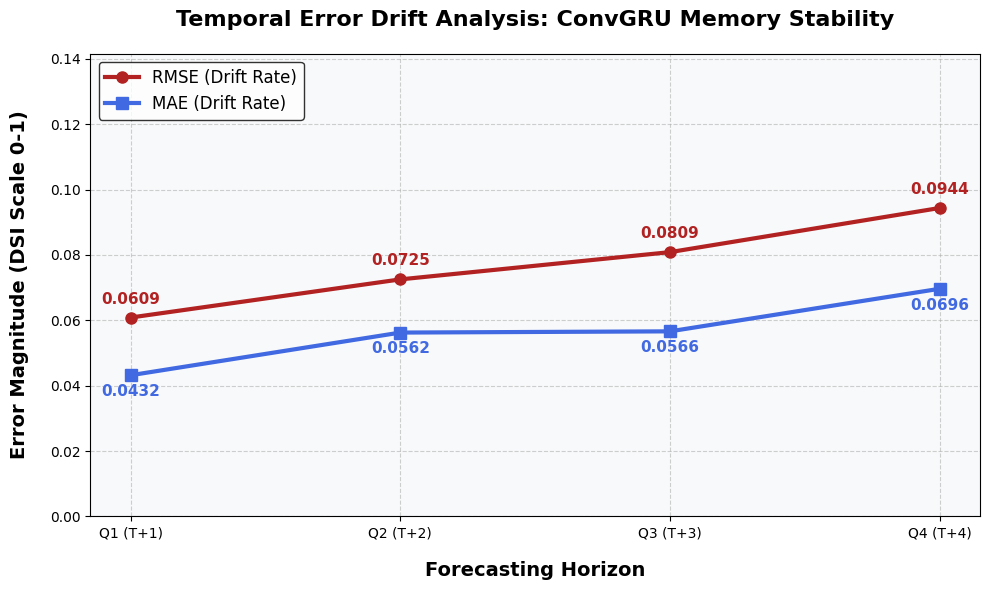


 TEMPORAL ERROR DRIFT (MODEL B)
 Q1 (T+1)   | MAE: 0.0432 | RMSE: 0.0609
 Q2 (T+2)   | MAE: 0.0562 | RMSE: 0.0725
 Q3 (T+3)   | MAE: 0.0566 | RMSE: 0.0809
 Q4 (T+4)   | MAE: 0.0696 | RMSE: 0.0944
[*] Chart successfully saved to: /kaggle/working/checkpoints_convgru/Temporal_Error_Drift_ModelB.png


In [16]:
# Execute the analysis
run_standalone_temporal_drift()

## Test Time Augmentation

In [17]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_convgru"

def run_global_tta_uncertainty():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Global TTA Uncertainty Estimation on: {device}")

    # --- 2. LOAD MODEL ---
    model = SindhConvGRUUNet(base_ch=32).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "convgru_best.pth"), map_location=device))
    model.eval()

    # --- 3. LOAD TEST DATASET ---
    test_ds = SindhConvGRUTestDataset(TEST_DIR, seq_len=4, total_months=26, step_size=3)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

    total_uncertainty_t4 = 0.0
    total_pixels_t4 = 0
    max_global_uncertainty = 0.0

    # --- 4. RUN GLOBAL ENSEMBLE INFERENCE ---
    with torch.no_grad():
        # X: (B, 4, 1, 64, 64)
        for X, _, _ in tqdm(test_loader, desc="Calculating Global Confidence"):
            X = X.to(device)
            
            # Create the 4 spatial augmentations for the whole batch
            X_aug_list = [
                X,                                  # 0: Original
                torch.flip(X, dims=[4]),            # 1: Flip Horizontal
                torch.flip(X, dims=[3]),            # 2: Flip Vertical
                torch.rot90(X, k=1, dims=[3, 4])    # 3: Rotate 90
            ]
            
            batch_preds = []
            
            for i, X_aug in enumerate(X_aug_list):
                # Predict (B, 4, 1, 64, 64)
                pred = model(X_aug, target_seq=None, teacher_forcing_ratio=0.0)
                pred = torch.clamp(pred, 0.0, 1.0)
                
                # Reverse the augmentation
                if i == 0:
                    pred_aligned = pred
                elif i == 1:
                    pred_aligned = torch.flip(pred, dims=[4])
                elif i == 2:
                    pred_aligned = torch.flip(pred, dims=[3])
                elif i == 3:
                    pred_aligned = torch.rot90(pred, k=-1, dims=[3, 4])
                    
                batch_preds.append(pred_aligned)

            # Stack: (4_Augs, B, 4_TimeSteps, 1, 64, 64)
            stacked_preds = torch.stack(batch_preds, dim=0)
            
            # Calculate Standard Deviation across the 4 augmentations (dim=0)
            # Resulting shape: (B, 4_TimeSteps, 1, 64, 64)
            std_dev = torch.std(stacked_preds, dim=0)
            
            # We specifically want to look at T+4 (index 3), the furthest horizon
            # because that is where the model should be the MOST uncertain.
            std_t4 = std_dev[:, 3, :, :, :]
            
            total_uncertainty_t4 += torch.sum(std_t4).item()
            total_pixels_t4 += std_t4.numel()
            
            batch_max = torch.max(std_t4).item()
            if batch_max > max_global_uncertainty:
                max_global_uncertainty = batch_max

    # --- 5. FINAL CALCULATION ---
    global_mean_uncertainty = total_uncertainty_t4 / total_pixels_t4

    print("\n" + "=" * 60)
    print(" GLOBAL PREDICTIVE CONFIDENCE RESULTS (T+4 HORIZON)")
    print("=" * 60)
    print(f" Total Patches Tested       : {len(test_ds)}")
    print(f" Total Pixels Tested (T+4)  : {total_pixels_t4:,}")
    print(f" Global Mean Uncertainty    : {global_mean_uncertainty:.4f} (\u03C3)")
    print(f" Global Max Uncertainty     : {max_global_uncertainty:.4f} (\u03C3)")
    print("=" * 60)

In [18]:
run_global_tta_uncertainty()

[*] Running Global TTA Uncertainty Estimation on: cuda
  Patches        : 500
  Windows/patch  : 5
  Total samples  : 2,500


Calculating Global Confidence: 100%|██████████| 157/157 [00:16<00:00,  9.61it/s]


 GLOBAL PREDICTIVE CONFIDENCE RESULTS (T+4 HORIZON)
 Total Patches Tested       : 2500
 Total Pixels Tested (T+4)  : 10,240,000
 Global Mean Uncertainty    : 0.0519 (σ)
 Global Max Uncertainty     : 0.5774 (σ)


In [19]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_convgru"
SAVE_UNCERTAINTY_PATH = os.path.join(CHECKPOINT_DIR, "Predictive_Uncertainty_Map.png")

def run_tta_uncertainty_mapping():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running TTA Uncertainty Estimation on: {device}")

    # --- 2. LOAD MODEL ---
    model = SindhConvGRUUNet(base_ch=32).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "convgru_best.pth"), map_location=device))
    model.eval()

    # --- 3. GRAB A TEST PATCH ---
    # We grab the first file to demonstrate the spatial uncertainty
    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.pt')]
    sample_file = test_files[0]
    
    print(f"[*] Extracting sequence from: {sample_file}")
    patch = torch.load(os.path.join(TEST_DIR, sample_file), weights_only=True)
    
    # Grab the first 4 quarters (12 months) as our input history
    X_raw = patch[0:12:3, 37, :, :].unsqueeze(1).unsqueeze(0).to(device) # Shape: (1, 4, 1, 64, 64)
    
    # --- 4. CREATE TTA BATCH (Augmentations) ---
    # We will create 4 spatial variations of the exact same input
    X_aug_list = [
        X_raw,                                  # 0: Original
        torch.flip(X_raw, dims=[4]),            # 1: Flip Horizontal (W dimension)
        torch.flip(X_raw, dims=[3]),            # 2: Flip Vertical (H dimension)
        torch.rot90(X_raw, k=1, dims=[3, 4])    # 3: Rotate 90 degrees
    ]

    predictions = []

    # --- 5. RUN PREDICTIONS & REVERSE AUGMENTATIONS ---
    with torch.no_grad():
        for i, X_aug in enumerate(X_aug_list):
            # Predict 4 future quarters 
            # Output shape: (1, 4, 1, 64, 64)
            pred = model(X_aug, target_seq=None, teacher_forcing_ratio=0.0)
            pred = torch.clamp(pred, 0.0, 1.0)
            
            # Reverse the spatial augmentation so the outputs align physically
            if i == 0:
                pred_aligned = pred
            elif i == 1:
                pred_aligned = torch.flip(pred, dims=[4])
            elif i == 2:
                pred_aligned = torch.flip(pred, dims=[3])
            elif i == 3:
                pred_aligned = torch.rot90(pred, k=-1, dims=[3, 4])
                
            predictions.append(pred_aligned.cpu().numpy().squeeze())

    # Stack predictions: Shape becomes (4_Augmentations, 4_TimeSteps, 64, 64)
    predictions = np.stack(predictions, axis=0)

    # --- 6. CALCULATE UNCERTAINTY (Standard Deviation) ---
    # We calculate the mean and standard deviation across the 4 augmentations
    # Let's look at the final forecasted step (T+4)
    target_timestep = 3 
    
    mean_prediction = np.mean(predictions[:, target_timestep, :, :], axis=0)
    uncertainty_map = np.std(predictions[:, target_timestep, :, :], axis=0)
    
    max_uncertainty = np.max(uncertainty_map)
    mean_uncertainty = np.mean(uncertainty_map)

    # --- 7. PLOT THE RESULTS ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
    fig.patch.set_facecolor('#f8f9fa')

    # A. The Mean Prediction (What the model actually forecasts)
    im0 = axes[0].imshow(mean_prediction, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[0].set_title("1. T+4 Forecasted Severity (Ensemble Mean)", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # B. The Uncertainty Map (Standard Deviation)
    # We use the 'magma' colormap. Dark/Black = Certain, Bright Yellow/White = Highly Uncertain
    im1 = axes[1].imshow(uncertainty_map, cmap='magma', vmin=0, vmax=0.05) 
    axes[1].set_title(f"2. Predictive Confidence ($\sigma$)\n(Mean Uncertainty: {mean_uncertainty:.4f})", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label('Standard Deviation (Higher = More Uncertain)', rotation=270, labelpad=20)

    plt.suptitle("Model B Confidence: TTA Uncertainty Mapping", fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(SAVE_UNCERTAINTY_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("\n" + "=" * 50)
    print(" PREDICTIVE CONFIDENCE RESULTS (T+4)")
    print("=" * 50)
    print(f" Mean Spatial Uncertainty : {mean_uncertainty:.4f}")
    print(f" Max Localized Uncertainty: {max_uncertainty:.4f}")
    print("=" * 50)

<>:90: SyntaxWarning: invalid escape sequence '\s'
<>:90: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55/1040589672.py:90: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title(f"2. Predictive Confidence ($\sigma$)\n(Mean Uncertainty: {mean_uncertainty:.4f})", fontsize=14, fontweight='bold')


[*] Running TTA Uncertainty Estimation on: cuda
[*] Extracting sequence from: Patch_125_Strata_1.pt


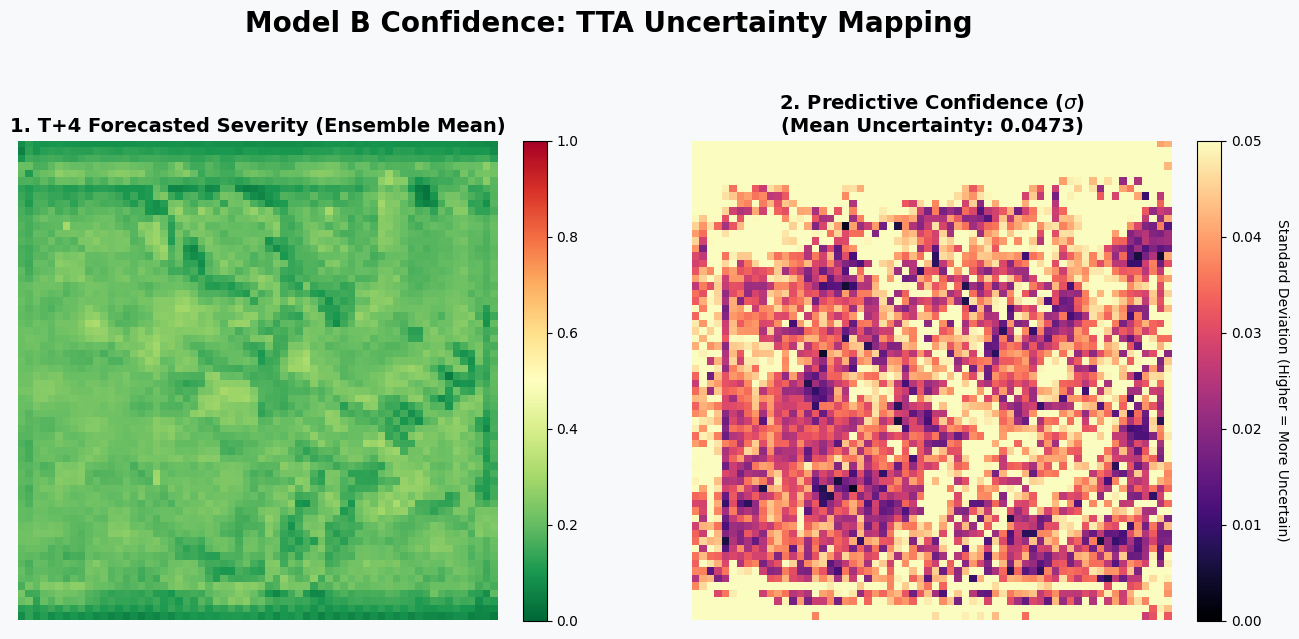


 PREDICTIVE CONFIDENCE RESULTS (T+4)
 Mean Spatial Uncertainty : 0.0473
 Max Localized Uncertainty: 0.1864


In [20]:
run_tta_uncertainty_mapping()